## Predictive Analysis with Titanic Challenge

## Load Libraries and files


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# for data prep 
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
# for evaluation
from sklearn.metrics import confusion_matrix, classification_report
#for analysis 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier


In [3]:
#import data 
df = pd.read_csv('train.csv')
testData = pd.read_csv('test.csv')

## EDA

In [4]:
#Convert datatypes 
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df['Sex']= df['Sex'].astype('category')
df['PassengerId'] = df['PassengerId'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')
df['Survived'] = df['Survived'].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    category
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    str     
 11  Embarked     889 non-null    category
dtypes: category(4), float64(2), int64(3), str(3)
memory usage: 67.2 KB


In [7]:
#find missing values
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
testData.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [9]:
#handle missing data
df['Age'] = df['Age'].fillna(df['Age'].mean())
testData['Age'] = testData['Age'].fillna(testData['Age'].mean())
testData['Fare'] = testData['Fare'].fillna(testData['Fare'].mean())

#handle missing categorical data
df['Embarked']. value_counts()


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [10]:
#fill out missing values for Embarked
df['Embarked'] = df['Embarked'].fillna('S')


In [11]:
#encode cat var for easy analysis
le_dict ={}
for col in ['Sex', 'Embarked']:
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col])
    testData[col] = le.transform(testData[col])
    
    le_dict[col]= le #save encoder dictionary
    
    print(f"Endcoding for '{col}':")
    for i, class_label in enumerate(le.classes_):
        print(f"[class_label]-->{i}")
    
    
    

Endcoding for 'Sex':
[class_label]-->0
[class_label]-->1
Endcoding for 'Embarked':
[class_label]-->0
[class_label]-->1
[class_label]-->2


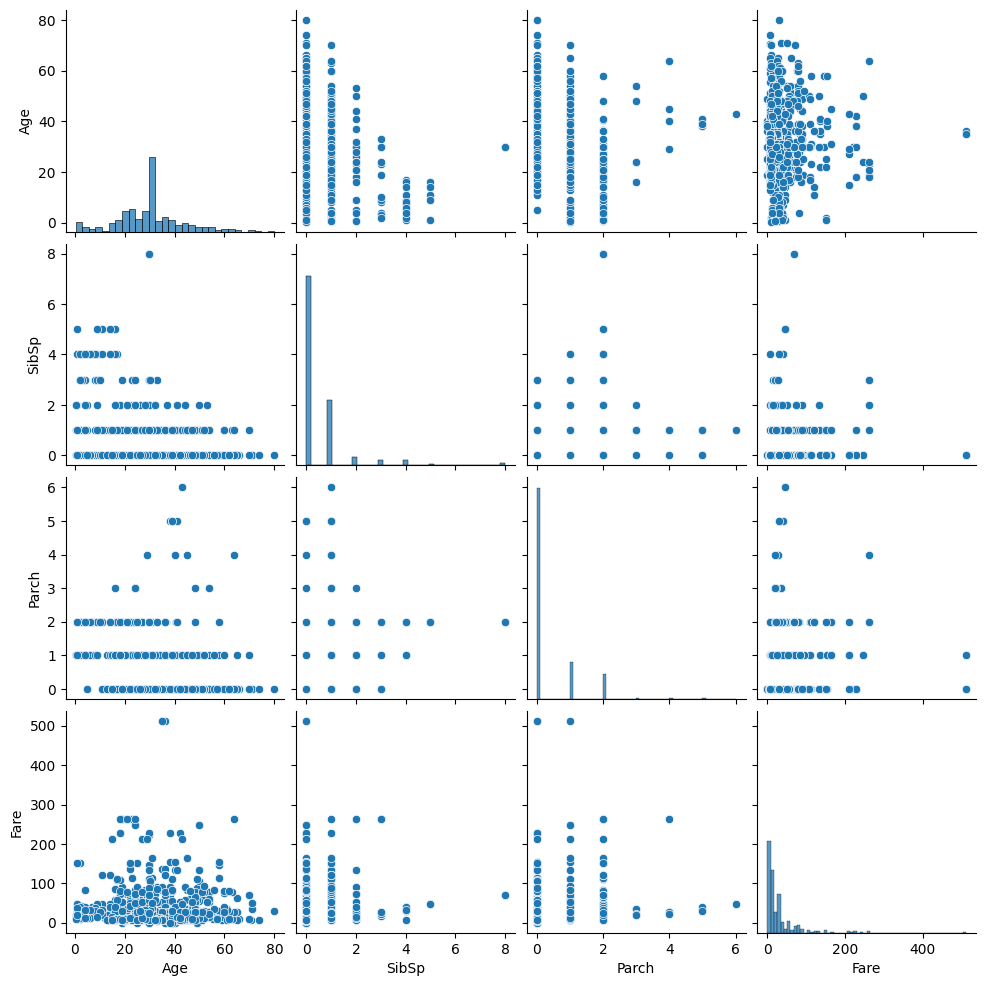

In [12]:
#Corr map of numerical variables
sns.pairplot(df[['Age', 'SibSp', 'Parch', 'Fare']])

<Axes: xlabel='Survived', ylabel='Age'>

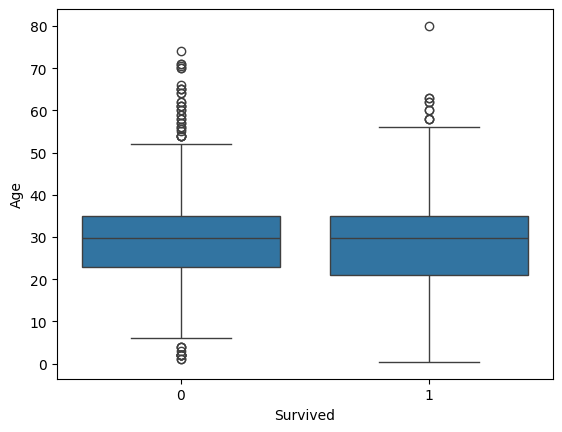

In [13]:
#boxplot between outcome and numerical var
sns.boxplot(x='Survived', y='Age', data = df)

## Data Preparation

In [14]:
# split the training dataset into training and validation
# x = [['Pclass', 'Sex', 'Age', 'SibSp','Parch', 'Fare','Embarked']]
# go back after looking at the tree, keep only the important features. 
features_list = x = ['Pclass','Sex', 'Age','Fare']
x = df[features_list]
y = df['Survived'].astype(int)
x_train, x_val, y_train, y_val = train_test_split (x,y, test_size = 0.2, stratify = y, random_state=11)

## Model 1: decision tree

In [15]:
tree_model = DecisionTreeClassifier(random_state=11)
tree_model.fit (x_train, y_train)
tree_pred = tree_model.predict(x_val)


In [25]:
# produce confusion matrix 
print (confusion_matrix(y_val, tree_pred))
print (classification_report(y_val, tree_pred))

[[92 18]
 [22 47]]
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       110
           1       0.72      0.68      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.77      0.78      0.78       179



In [16]:
#feature importance ranking
importance = tree_model.feature_importances_
feature_importances_df = pd.DataFrame({'Feature': x.columns, 'Importance': importance}).sort_values(by = 'Importance', ascending = False)
print(feature_importances_df)

  Feature  Importance
3    Fare    0.326824
1     Sex    0.290280
2     Age    0.290027
0  Pclass    0.092869


<function matplotlib.pyplot.show(close=None, block=None)>

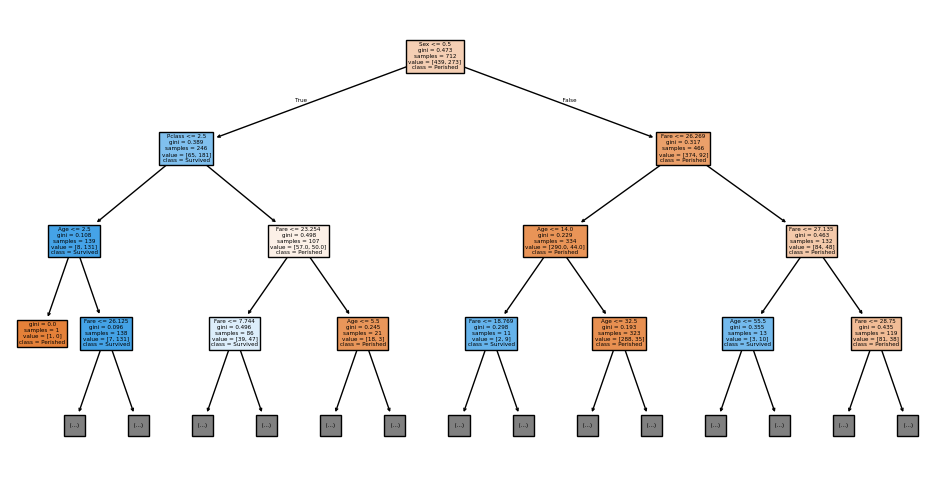

In [17]:
#visualize the tree
plt.figure(figsize = (12,6))
plot_tree(tree_model, feature_names=x.columns,
          class_names=['Perished', 'Survived'], filled=True, max_depth=3)

#save the photo
plt.savefig("titanic_tree.png", dpi = 300)
plt.show

## Model 2: Random Forest

In [26]:
rf_model = RandomForestClassifier(n_estimators=100, #how many free in the forest
                                 random_state=11)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_val)


In [27]:
# produce confusion matrix 
print (confusion_matrix(y_val, rf_pred))
print (classification_report(y_val, rf_pred))

[[99 11]
 [17 52]]
              precision    recall  f1-score   support

           0       0.85      0.90      0.88       110
           1       0.83      0.75      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



## Model 3:  Neural Net

In [28]:
nn_model = MLPClassifier( hidden_layer_sizes=(100,), max_iter=1000, random_state=11)
nn_model.fit(x_train, y_train)
nn_pred = nn_model.predict(x_val)


In [30]:
# produce confusion matrix 
print (confusion_matrix(y_val, nn_pred))
print (classification_report(y_val, nn_pred))

[[93 17]
 [22 47]]
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       110
           1       0.73      0.68      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



## Model 4: Gradient Boosting Decision Tree


In [31]:
gbdt_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=11)
gbdt_model.fit(x_train, y_train)
gbdt_pred = gbdt_model.predict(x_val)


In [32]:
# produce confusion matrix 
print (confusion_matrix(y_val, gbdt_pred))
print (classification_report(y_val, gbdt_pred))

[[100  10]
 [ 23  46]]
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       110
           1       0.82      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



## Deploy

In [21]:
# Apply Descision tree model in the testing dataset
#final_predict = tree_model.predict(testData[['Pclass', 'Sex', 'Age', 'SibSp','Parch', 'Fare','Embarked']])
final_predict = tree_model.predict(testData[features_list])

submission0 = pd.DataFrame({
    'PassengerID': testData['PassengerId'],
    'Survived': final_predict
})

submission0.to_csv('titanic_tree.csv', index= False)

In [22]:
# Apply Random Forest model in the testing dataset
#final_predict = tree_model.predict(testData[['Pclass', 'Sex', 'Age', 'SibSp','Parch', 'Fare','Embarked']])
final_predict = rf_model.predict(testData[features_list])

submission1 = pd.DataFrame({
    'PassengerID': testData['PassengerId'],
    'Survived': final_predict
})

submission1.to_csv('titanic_rf.csv', index= False)

In [23]:
# Apply Neural Network model in the testing dataset
#final_predict = tree_model.predict(testData[['Pclass', 'Sex', 'Age', 'SibSp','Parch', 'Fare','Embarked']])
final_predict = nn_model.predict(testData[features_list])

submission2 = pd.DataFrame({
    'PassengerID': testData['PassengerId'],
    'Survived': final_predict
})

submission2.to_csv('titanic_nn.csv', index= False)

In [24]:
# Apply Gradient Boosted Descision Tree model in the testing dataset
#final_predict = tree_model.predict(testData[['Pclass', 'Sex', 'Age', 'SibSp','Parch', 'Fare','Embarked']])
final_predict = gbdt_model.predict(testData[features_list])

submission3 = pd.DataFrame({
    'PassengerID': testData['PassengerId'],
    'Survived': final_predict
})

submission3.to_csv('titanic_gbdt.csv', index= False)